# Gradient Boosting — PD vs CN
Subject-level aggregation with adjustable GB parameters.  
Runs in under a minute.

---

In [1]:
CYMO_CSV = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'
META_CSV = './cymo_parkceleb_per_recording_metadata.csv'
FEAT_CSV = './mrmr_top10_features.csv'

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib, warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix, roc_curve, auc
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titleweight': 'bold'})

In [3]:
# Load and aggregate
cymo = pd.read_csv(CYMO_CSV)
meta = pd.read_csv(META_CSV)
features = pd.read_csv(FEAT_CSV)['feature'].tolist()
tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]
df = cymo.merge(meta[[meta_tid, 'group', 'subject']].drop_duplicates(),
                left_on=tid_col, right_on=meta_tid, how='inner')
df['label'] = (df['group'] == 'PD').astype(int)
for col in features:
    df[col] = pd.to_numeric(df.get(col, 0), errors='coerce')
df[features] = df[features].fillna(df[features].median())

#agg = {f: ['mean', 'std'] for f in features}
#agg['label'] = 'first'
#subj = df.groupby('subject').agg(agg).reset_index()
#subj.columns = ['subject'] + [f'{a}_{b}' if b else a for a, b in subj.columns[1:]]
#label_col = [c for c in subj.columns if 'label' in c][0]
#subj = subj.rename(columns={label_col: 'label'}).fillna(0)
#eat_cols = [c for c in subj.columns if c not in ('subject', 'label')]
agg = {f: 'mean' for f in features}
agg['label'] = 'first'
subj = df.groupby('subject').agg(agg).reset_index()
subj = subj.fillna(0)
feat_cols = features  # same 24 features as RF
print(f'{len(subj)} subjects, {len(feat_cols)} features')
print(f'{len(subj)} subjects, {len(feat_cols)} features')

100 subjects, 24 features
100 subjects, 24 features


In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║  ADJUST GB PARAMETERS HERE                              ║
# ╚══════════════════════════════════════════════════════════╝
gb_configs = [
    # n_estimators, max_depth, learning_rate, min_samples_leaf, subsample
    (50,   2, 0.1,  3, 1.0),
    (50,   3, 0.1,  3, 1.0),
    (100,  2, 0.1,  3, 1.0),
    (100,  3, 0.1,  3, 1.0),
    (100,  3, 0.05, 3, 1.0),
    (100,  3, 0.1,  5, 1.0),
    (200,  2, 0.05, 3, 1.0),
    (200,  3, 0.05, 3, 1.0),
    (200,  3, 0.1,  3, 0.8),   # stochastic GB (subsample < 1)
    (200,  3, 0.05, 3, 0.8),
    (100,  2, 0.1,  3, 0.8),
    (300,  2, 0.05, 3, 0.8),
]

N_SPLITS = 20

In [5]:
results = []
for n, d, lr, ml, ss in gb_configs:
    for seed in range(N_SPLITS):
        cn = subj[subj['label']==0].sample(frac=1, random_state=seed)
        pd_g = subj[subj['label']==1].sample(frac=1, random_state=seed)
        cs, ps = int(len(cn)*0.7), int(len(pd_g)*0.7)
        train = pd.concat([cn.iloc[:cs], pd_g.iloc[:ps]])
        test = pd.concat([cn.iloc[cs:], pd_g.iloc[ps:]])

        sc = StandardScaler()
        X_tr = sc.fit_transform(train[feat_cols].values)
        X_te = sc.transform(test[feat_cols].values)
        y_te = test['label'].values

        gb = GradientBoostingClassifier(
            n_estimators=n, max_depth=d, learning_rate=lr,
            min_samples_leaf=ml, subsample=ss, random_state=42)
        gb.fit(X_tr, train['label'].values)
        y_prob = gb.predict_proba(X_te)[:, 1]
        y_pred = gb.predict(X_te)

        results.append({
            'n': n, 'd': d, 'lr': lr, 'ml': ml, 'ss': ss, 'seed': seed,
            'acc': accuracy_score(y_te, y_pred),
            'auc': roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5,
            'f1': f1_score(y_te, y_pred, zero_division=0),
            'sens': recall_score(y_te, y_pred, zero_division=0),
            'spec': recall_score(y_te, y_pred, pos_label=0, zero_division=0),
        })

res_df = pd.DataFrame(results)
res_df['config'] = res_df.apply(
    lambda r: f"n={r['n']} d={r['d']} lr={r['lr']} ml={r['ml']} ss={r['ss']}", axis=1)
print(f'Done: {len(res_df)} experiments')

Done: 240 experiments


In [6]:
# Summary
summary = res_df.groupby('config').agg(
    acc=('acc','mean'), acc_std=('acc','std'),
    auc=('auc','mean'), auc_std=('auc','std'),
    f1=('f1','mean'), sens=('sens','mean'), spec=('spec','mean'),
).sort_values('auc', ascending=False).round(3)

print(f'{"Config":<45s} {"Acc":>12s} {"AUC":>12s} {"F1":>6s} {"Sens":>6s} {"Spec":>6s}')
print('─' * 90)
for cfg, r in summary.iterrows():
    print(f'{cfg:<45s} {r["acc"]:.3f}±{r["acc_std"]:.3f} '
          f'{r["auc"]:.3f}±{r["auc_std"]:.3f} {r["f1"]:.3f} {r["sens"]:.3f} {r["spec"]:.3f}')

Config                                                 Acc          AUC     F1   Sens   Spec
──────────────────────────────────────────────────────────────────────────────────────────
n=200.0 d=3.0 lr=0.1 ml=3.0 ss=0.8            0.813±0.074 0.864±0.062 0.750 0.712 0.881
n=200.0 d=3.0 lr=0.05 ml=3.0 ss=0.8           0.815±0.065 0.860±0.063 0.751 0.712 0.883
n=100.0 d=2.0 lr=0.1 ml=3.0 ss=0.8            0.812±0.070 0.855±0.061 0.750 0.721 0.872
n=100.0 d=3.0 lr=0.1 ml=3.0 ss=1.0            0.797±0.072 0.854±0.072 0.734 0.712 0.853
n=300.0 d=2.0 lr=0.05 ml=3.0 ss=0.8           0.812±0.065 0.854±0.061 0.753 0.729 0.867
n=200.0 d=3.0 lr=0.05 ml=3.0 ss=1.0           0.788±0.081 0.848±0.073 0.722 0.700 0.847
n=50.0 d=3.0 lr=0.1 ml=3.0 ss=1.0             0.795±0.072 0.848±0.073 0.727 0.696 0.861
n=200.0 d=2.0 lr=0.05 ml=3.0 ss=1.0           0.802±0.055 0.847±0.070 0.733 0.700 0.869
n=100.0 d=2.0 lr=0.1 ml=3.0 ss=1.0            0.802±0.061 0.847±0.067 0.733 0.700 0.869
n=100.0 d=3.0 lr=0.05 ml

In [7]:
# Train best config and save
best_cfg_name = summary.index[0]
best_row = res_df[res_df['config'] == best_cfg_name].iloc[0]

np.random.seed(42)
cn = subj[subj['label']==0].sample(frac=1, random_state=42)
pd_g = subj[subj['label']==1].sample(frac=1, random_state=42)
cs, ps = int(len(cn)*0.7), int(len(pd_g)*0.7)
train = pd.concat([cn.iloc[:cs], pd_g.iloc[:ps]])
test = pd.concat([cn.iloc[cs:], pd_g.iloc[ps:]])

sc = StandardScaler()
X_tr = sc.fit_transform(train[feat_cols].values)
X_te = sc.transform(test[feat_cols].values)

best_gb = GradientBoostingClassifier(
    n_estimators=int(best_row['n']), max_depth=int(best_row['d']),
    learning_rate=best_row['lr'], min_samples_leaf=int(best_row['ml']),
    subsample=best_row['ss'], random_state=42)
best_gb.fit(X_tr, train['label'].values)

y_pred = best_gb.predict(X_te)
y_prob = best_gb.predict_proba(X_te)[:, 1]
y_te = test['label'].values

print(f'Best: {best_cfg_name}')
print(f'  Acc={accuracy_score(y_te,y_pred):.3f}  AUC={roc_auc_score(y_te,y_prob):.3f}  '
      f'F1={f1_score(y_te,y_pred):.3f}')

joblib.dump({'model': best_gb, 'scaler': sc, 'features': feat_cols,
             'base_features': features, 'aggregation': 'subject_mean_std'}, 'gb_best.joblib')
print('Saved: gb_best.joblib')

Best: n=200.0 d=3.0 lr=0.1 ml=3.0 ss=0.8
  Acc=0.867  AUC=0.963  F1=0.833
Saved: gb_best.joblib


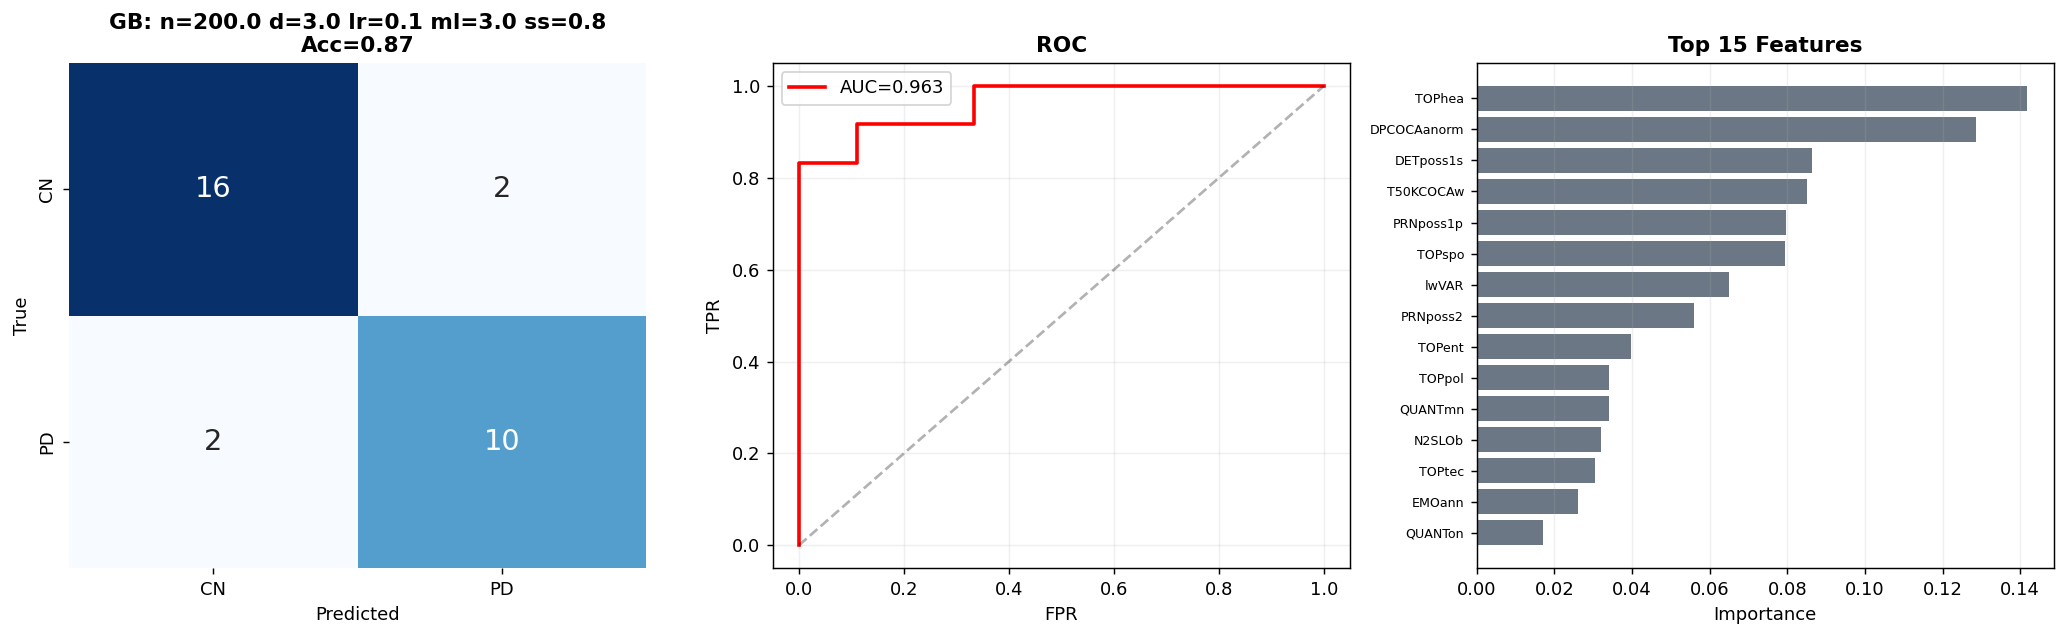

In [8]:
# Visuals
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['CN','PD'], yticklabels=['CN','PD'], cbar=False, annot_kws={'size':16})
axes[0].set_title(f'GB: {best_cfg_name}\nAcc={accuracy_score(y_te,y_pred):.2f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# ROC
fpr, tpr, _ = roc_curve(y_te, y_prob)
axes[1].plot(fpr, tpr, 'r-', lw=2, label=f'AUC={roc_auc_score(y_te,y_prob):.3f}')
axes[1].plot([0,1],[0,1],'k--',alpha=0.3); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC'); axes[1].legend(); axes[1].grid(alpha=0.2)

# Feature importance
imp = best_gb.feature_importances_
idx = np.argsort(imp)[::-1][:15]  # top 15
axes[2].barh(range(len(idx)), imp[idx], color='#2C3E50', alpha=0.7)
axes[2].set_yticks(range(len(idx))); axes[2].set_yticklabels([feat_cols[i] for i in idx], fontsize=7)
axes[2].set_xlabel('Importance'); axes[2].set_title('Top 15 Features')
axes[2].invert_yaxis(); axes[2].grid(axis='x', alpha=0.2)

plt.tight_layout(); plt.savefig('gb_results.png', dpi=150, bbox_inches='tight'); plt.show()

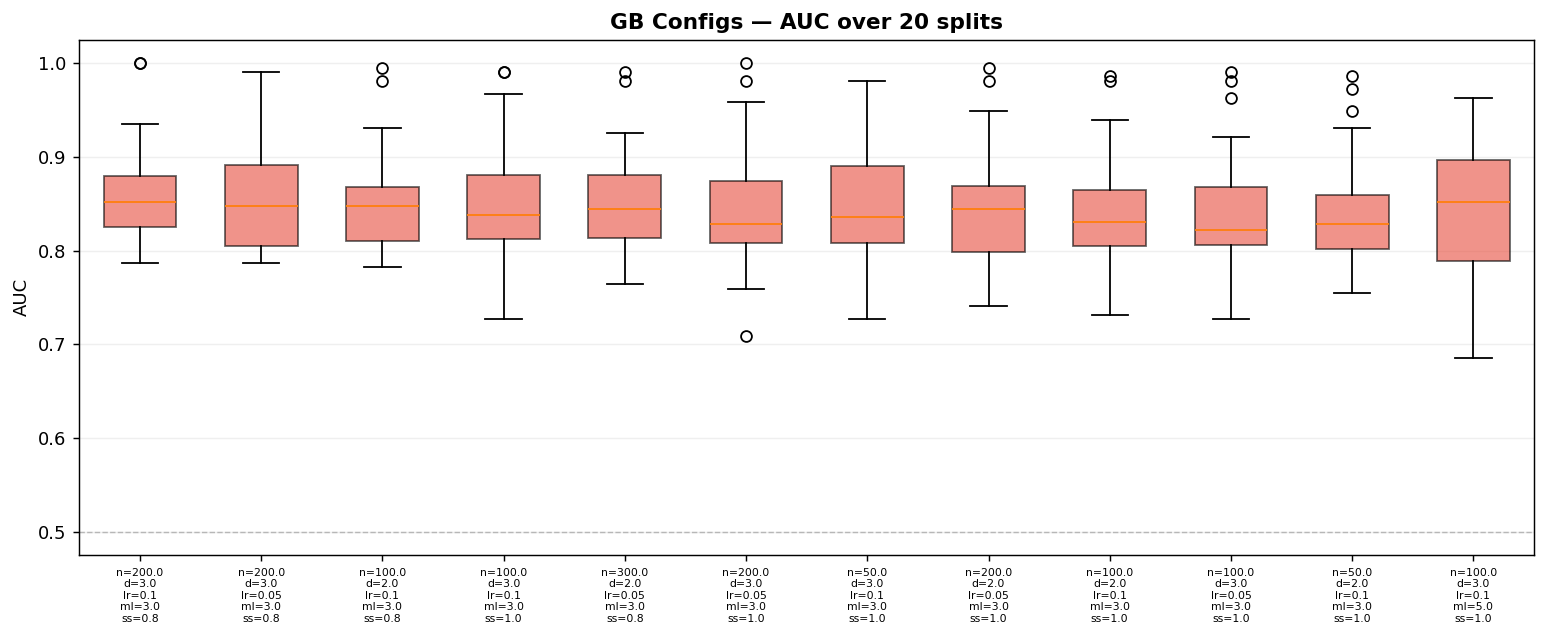

In [9]:
# Box plot comparison
fig, ax = plt.subplots(figsize=(12, 5))
order = summary.index.tolist()
data = [res_df[res_df['config']==c]['auc'].values for c in order]
bp = ax.boxplot(data, labels=[c.replace(' ','\n') for c in order], patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor('#E74C3C'); patch.set_alpha(0.6)
ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.set_ylabel('AUC'); ax.set_title(f'GB Configs — AUC over {N_SPLITS} splits')
ax.tick_params(axis='x', labelsize=6); ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.savefig('gb_comparison.png', dpi=150, bbox_inches='tight'); plt.show()